## Data preprocessing


In [79]:
import json
import numpy as np
from gensim.models import KeyedVectors
from gensim.models import Word2Vec
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pandas as pd
import random
import pickle
from utils import load_data, create_embedding_matrix, preprocess_text, to_padding, pad_sequences
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.metrics import precision_recall_fscore_support


In [2]:
class MyTokenizer:
    def __init__(self):
        self.word_index = {"<PAD>": 0, "<UNK>": 1}
        self.idx_to_token = {0: "<PAD>", 1: "<UNK>"}
        
    def fit_on_texts(self, texts):
        for text in texts:
            for word in text.split():
                if word not in self.word_index:
                    self.word_index[word] = len(self.word_index)
                    self.idx_to_token[self.word_index[word]] = word

    def text_to_sequences(self, text):
        return [self.word_index.get(word, self.word_index["<UNK>"]) for word in text.split()]
    
    def texts_to_sequences(self, texts):
        return [[self.word_index.get(word, self.word_index["<UNK>"]) for word in text.split()] for text in texts]


    def encode(self, text, max_length):
        tokens = self.text_to_sequences(text)
        if len(tokens) < max_length:
            tokens += [self.word_index["<PAD>"]] * (max_length - len(tokens))
        else:
            tokens = tokens[:max_length]
        return tokens
    
    def __call__(self, claims, evidences, max_length=512, return_tensors="pt"):
        self.fit_on_texts([claims, evidences])
        encoded_claims = self.encode(claims, max_length)
        encoded_evidences = self.encode(evidences, max_length)
        if return_tensors == "pt":
            return {
                "input_ids": torch.tensor([encoded_claims, encoded_evidences], dtype=torch.long)
            }
        return {"input_ids": [encoded_claims, encoded_evidences]}


In [3]:
# nltk.download('punkt')
stop_words = set(stopwords.words('english'))
stemmer =  SnowballStemmer('english')

train_claims_data = load_data('../data/train-claims.json')
evidence_data = load_data('../data/evidence.json')
dev_claims_data = load_data('../data/dev-claims.json')
# evidence_map = load_data('../data/curated/preprocessed_evidence_map.json')  
evidence_map = load_data('../data/curated/mild_nostopwords_evidence.json')  
filtered_evidence_map = load_data('../data/curated/mild_nostopwords_filtered_evidence.json')

In [71]:
label_mapping = {
    "SUPPORTS": 1,
    "REFUTES": -1,
    "DISPUTED": 0,
    "NOT_ENOUGH_INFO": 0
}
data_for_dataframe = []
for claim_id, claim_details in train_claims_data.items():
    claim_text = claim_details['claim_text']
    claim_label = claim_details['claim_label']
    eids = claim_details['evidences']
    for eid in eids:
        evidence_text = evidence_map[eid]
        data_for_dataframe.append({
                'claim_id': claim_id,
                'claim': preprocess_text(claim_text, stemmer=stemmer, stop_words=None),
                'evidence': evidence_text,
                'label': label_mapping[claim_label]
            })

# Create DataFrame
train_claims_df = pd.DataFrame(data_for_dataframe)

# train_claims_df['evidence_texts'] = train_claims_df['evidence'].apply(
#     lambda x: ' '.join([evidence_map[evidence_id] for evidence_id in x])
# )

train_claims_df

,claim_id,claim,evidence,label
0,claim-1937,not onli is there no scientif evid that co2 is...,at veri high concentr 100 time atmospher conce...,0
1,claim-1937,not onli is there no scientif evid that co2 is...,plant can grow as much as 50 percent faster in...,0
2,claim-1937,not onli is there no scientif evid that co2 is...,higher carbon dioxid concentr will favour affe...,0
3,claim-126,el niño drove record high in global temperatur...,while climat chang can be due to natur forc or...,-1
4,claim-126,el niño drove record high in global temperatur...,this acceler is due most to human caus global ...,-1
...,...,...,...,...
4117,claim-502,but abnorm temperatur spike in februari and ea...,the coastlin see signific mild temperatur when...,0
4118,claim-3093,send oscil microwav from an antenna insid a va...,dielectr heat also known as electron heat radi...,1
4119,claim-3093,send oscil microwav from an antenna insid a va...,an exampl is absorpt or emiss of radio wave by...,1
4120,claim-3093,send oscil microwav from an antenna insid a va...,water fat and other substanc in the food absor...,1


In [72]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(train_claims_df, test_size=0.2, random_state=42)
train_df

,claim_id,claim,evidence,label
1146,claim-1579,a drop in volcan activ caus warm,further methan is a potent greenhous gas as it...,0
2984,claim-2520,accord to the second law of thermodynam such a...,this result now known as the second law of bla...,0
3888,claim-2111,global warm and climat chang mean differ thing...,scientist have identifi mani episod of climat ...,-1
2825,claim-508,climat project also assum that planet earth is...,despit such interact high accur simul show tha...,0
1921,claim-2406,this growth stimul occur becaus co2 is one of ...,the energi is use to reduc carbon dioxid from ...,1
...,...,...,...,...
3444,claim-1656,the natur cycl add and remov co2 to keep a bal...,sinc the industri revolut human activ has modi...,1
466,claim-1049,so far this month there have been near 5 000 d...,on averag there are 77 day of 90 32 high 8.1 d...,0
3092,claim-728,the sea was much colder than previous thought ...,this is much colder than the condit that actua...,1
3772,claim-621,dr gutzler said spring temperatur have an impa...,further exampl includ sea level rise widesprea...,0


In [89]:
# def text2seq(train_text, test_text, tokenizer):
#     # Fit the tokenizer only on the training data
#     tokenizer.fit_on_texts(train_text)

#     # Tokenize training and testing text
#     train_sequence = tokenizer.texts_to_sequences(train_text)
#     test_sequence = tokenizer.texts_to_sequences(test_text)

#     # Calculate the maximum length of sequences for padding
#     max_length = max(len(seq) for seq in train_sequence + test_sequence)

#     print("Max length:", max_length)

#     with open("tokenizer_train" + ".pickle", "wb") as handle:
#         pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

#     return train_sequence, tokenizer.word_index, test_sequence, max_length


# def to_padding(train_df, test_df, tokenizer):
#     # Tokenize and pad claims
#     x_claims_seq, x_claims_word_index, y_claims_seq, max_claims_length = text2seq(
#         train_df["claim"].tolist(),
#         test_df["claim"].tolist(),
#         tokenizer
#     )

#     # Tokenize and pad evidence texts
#     # Flatten list of evidence texts since they are lists within each row
#     # train_evidences = [text for sublist in train_df["evidence_texts"].tolist() for text in sublist]
#     # test_evidences = [text for sublist in test_df["evidence_texts"].tolist() for text in sublist]

#     x_sents_seq, x_sents_word_index, y_sents_seq, max_sents_length = text2seq(
#         train_df["evidence"].tolist(),
#          test_df["evidence"].tolist(),
#         tokenizer
#     )
def text2seq(train_text, test_text, tokenizer_name, tokenizer):
    # Fit the tokenizer on the entire dataset

    tokenizer.fit_on_texts(train_text + test_text)

    # Calculate the maximum length of sequences for padding
    max_length = max(
        max([len(text.split()) for text in train_text]),
        max([len(text.split()) for text in test_text]),
    )
    print("Max length:", max_length)

    # Tokenize each text individually
    train_sequence = [
        tokenizer.text_to_sequences(text) for text in train_text
    ]  # Process each text separately
    test_sequence = [
        tokenizer.text_to_sequences(text) for text in test_text
    ]  # Process each text separately
    # Dictionary of words to index
    input_text_index = tokenizer.word_index

    # Optionally, save the tokenizer
    with open(tokenizer_name + ".pickle", "wb") as handle:
        pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
    return train_sequence, input_text_index, test_sequence, max_length


def to_padding(train_df, test_df, tokenizer):
    # Initialize and fit the tokenizer on claim and evidence separately
    x_claims_seq, x_claims_word_index, y_claims_seq, max_claims_length = text2seq(
        train_df["claim"].tolist(),
        test_df["claim"].tolist(),
        "tokenizer_claims",
        tokenizer,
    )
    x_sents_seq, x_sents_word_index, y_sents_seq, max_sents_length = text2seq(
        train_df["evidence"].tolist(),
        test_df["evidence"].tolist(),
        "tokenizer_evidence",
        tokenizer,
    )

    # Padding sequences
    x_claims_data = pad_sequences(x_claims_seq, maxlen=max_claims_length)
    y_claims_data = pad_sequences(y_claims_seq, maxlen=max_claims_length)
    x_sents_data = pad_sequences(x_sents_seq, maxlen=max_sents_length)
    y_sents_data = pad_sequences(y_sents_seq, maxlen=max_sents_length)

    # x_labels = np.array([label_mapping[label] for label in train_df["label"].tolist()])
    # y_labels = np.array([label_mapping[label] for label in test_df["label"].tolist()])
    x_labels = np.array(train_df["label"].tolist())
    y_labels = np.array(test_df["label"].tolist())

    return (
        x_claims_data, x_sents_data, x_labels, x_claims_word_index,
        x_sents_word_index, y_claims_data, y_sents_data, y_labels
    )

def pad_sequences(sequences, maxlen=None):
    if maxlen is None:
        maxlen = max(len(seq) for seq in sequences)
    padded_sequences = np.zeros(
        (len(sequences), maxlen), dtype=int
    )  # Ensure dtype is int
    for i, sequence in enumerate(sequences):
        end = min(len(sequence), maxlen)
        padded_sequences[i, :end] = sequence[:end]
    return padded_sequences

In [90]:
tokenizer = MyTokenizer()
x_claim, x_sents, x_labels, x_claims_word_index,  x_sents_word_index, y_claims_data, y_sents_data, y_labels = to_padding(train_df, test_df, tokenizer)

print ("x claim word index ", len(x_claims_word_index))
print ("x sent word index ", len(x_sents_word_index))

vocab_size_claims = len(x_claims_word_index) + 2  # +1 for padding, +1 for <UNK>
vocab_size_evidences = len(x_sents_word_index) + 2

Max length: 66
Max length: 262
x claim word index  6707
x sent word index  6707


In [91]:
class EvidenceDataset(Dataset):
    def __init__(self, claims, evidences, labels):
        self.claims = claims
        self.evidences = evidences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        claim = torch.tensor(self.claims[idx], dtype=torch.long)
        evidence = torch.tensor(self.evidences[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        return {
            'claims': claim,
            'evidences': evidence,
            'labels': label
        }

# Assuming x_claim, y_claims_data, etc. are numpy arrays or lists of integers
train_dataset = EvidenceDataset(x_claim, x_sents, x_labels)
test_dataset = EvidenceDataset(y_claims_data, y_sents_data, y_labels)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


## Creating the Embedding Matrix

In [92]:
word_vectors = KeyedVectors.load('../word2vec.wordvectors', mmap='r')

In [93]:
embedding_dim = 300  # dimension of word2vec vectors
(embed_matrix_claim, embed_dim_claim) = create_embedding_matrix(vocab_size_claims, word_vectors, x_claims_word_index, embedding_dim)
(embed_matrix_evidence, embed_dim_evidence) = create_embedding_matrix(vocab_size_evidences, word_vectors, x_sents_word_index, embedding_dim)

print ("embed_matrix_claim shape ", embed_matrix_claim.shape)
print ("embed_matrix_evidence shape ", embed_matrix_evidence.shape)

embed_matrix_claim shape  (6709, 300)
embed_matrix_evidence shape  (6709, 300)


## Building the LSTM Model

We will build a simple unidirectional LSTM model to compare claim and evidence embeddings.

In [107]:
class BahdanauAttention(nn.Module):
    def __init__(self, feature_dim):
        super(BahdanauAttention, self).__init__()
        self.feature_dim = feature_dim
        self.key_layer = nn.Linear(feature_dim, feature_dim, bias=False)
        self.query_layer = nn.Linear(feature_dim, feature_dim, bias=False)
        self.energy_layer = nn.Linear(feature_dim, 1, bias=False)
        self._init_weights()

    def _init_weights(self):
        # Initialize weights using Xavier uniform distribution
        nn.init.xavier_uniform_(self.key_layer.weight)
        nn.init.xavier_uniform_(self.query_layer.weight)
        nn.init.xavier_uniform_(self.energy_layer.weight)

    def forward(self, values):
        query = self.query_layer(values)
        keys = self.key_layer(values)
        energy = torch.tanh(query + keys)
        energy = self.energy_layer(energy).squeeze(-1)
        attention_weights = F.softmax(energy, dim=1).unsqueeze(1)
        context = torch.bmm(attention_weights, values).squeeze(1)
        return context, attention_weights

class EvidenceModel(nn.Module):
    def __init__(self, vocab_size_claims, vocab_size_evidences, embed_dim_claim, embed_dim_evidence, num_classes):
        super(EvidenceModel, self).__init__()
        self.embedding_claims = nn.Embedding(vocab_size_claims, embed_dim_claim)
        self.lstm_claims_1 = nn.LSTM(embed_dim_claim, 256, batch_first=True, bidirectional=True)
        self.lstm_claims_2 = nn.LSTM(256*2, 64, batch_first=True, bidirectional=True)
        self.attention_claims = BahdanauAttention(64*2) 
        
        self.embedding_evidences = nn.Embedding(vocab_size_evidences, embed_dim_evidence)
        self.lstm_evidences_1 = nn.LSTM(embed_dim_evidence, 256, batch_first=True, bidirectional=True)
        self.lstm_evidences_2 = nn.LSTM(256*2, 16, batch_first=True, bidirectional=True)
        self.attention_evidences = BahdanauAttention(16*2)
        
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(80*2, 64)  # Adjust according to your concatenated feature size
        self.fc2 = nn.Linear(64, 1)  # Number of classes

        # Optionally freeze the embeddings
        self.embedding_claims.weight.requires_grad = False
        self.embedding_evidences.weight.requires_grad = False
    
    def forward(self, claims_input, evidences_input):
        embedded_claims = self.embedding_claims(claims_input)
        lstm_out_claims, _ = self.lstm_claims_1(embedded_claims)
        lstm_out_claims, _ = self.lstm_claims_2(lstm_out_claims)
        attentive_claims, _ = self.attention_claims(lstm_out_claims)

        embedded_evidences = self.embedding_evidences(evidences_input)
        lstm_out_evidences, _ = self.lstm_evidences_1(embedded_evidences)
        lstm_out_evidences, _ = self.lstm_evidences_2(lstm_out_evidences)
        attentive_evidences, _ = self.attention_evidences(lstm_out_evidences)

        concatenated = torch.cat((attentive_claims, attentive_evidences), dim=1)
        concatenated = self.dropout(concatenated)
        concatenated = self.fc1(concatenated)
        output = self.fc2(concatenated)
        return torch.tanh(output)

def train_model(model, train_loader, val_loader, epochs, device):
    model_path = '../checkpoints/BAttn_lstm_classify_tanh.pth'
    best_val_loss = float('inf')
    patience = 5
    trigger_times = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            claims = batch['claims'].to(device)
            evidences = batch['evidences'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(claims, evidences).squeeze(1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        val_loss = evaluate(model, val_loader, device)
        print(f'Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}')

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), model_path)
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            claims = batch['claims'].to(device)
            evidences = batch['evidences'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(claims, evidences).squeeze(1)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(loader)

def predict(model, data_loader, device):
    model.eval() 
    predictions = []
    with torch.no_grad():  
        for batch in data_loader:
            claims = batch['claims'].to(device)
            evidences = batch['evidences'].to(device)
            outputs = model(claims, evidences)
            predictions.append(outputs.cpu())  # Move predictions to CPU
            
    # Concatenate the list of tensors into a single tensor
    predictions = torch.cat(predictions, dim=0)
    return predictions


In [108]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EvidenceModel(vocab_size_claims, vocab_size_evidences, embed_dim_claim, embed_dim_evidence, 4).to(device)
# model = model = ClaimEvidenceModel(vocab_size_claims+vocab_size_evidences, embedding_dim, lstm_dim=128)
# criterion = nn.NLLLoss()  # Use Negative Log-Likelihood Loss with log_softmax
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# criterion = nn.CrossEntropyLoss()
criterion = nn.MSELoss()
# # optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Adding weight decay for L2 regularization


In [109]:

# Train the model
epochs = 60
train_model(model, train_loader, test_loader, epochs, device)

Epoch 1, Train Loss: 0.4077, Val Loss: 0.3960
Epoch 2, Train Loss: 0.3955, Val Loss: 0.3946
Epoch 3, Train Loss: 0.3956, Val Loss: 0.3940
Epoch 4, Train Loss: 0.3944, Val Loss: 0.3931
Epoch 5, Train Loss: 0.3891, Val Loss: 0.3897
Epoch 6, Train Loss: 0.3725, Val Loss: 0.3664
Epoch 7, Train Loss: 0.3293, Val Loss: 0.3404
Epoch 8, Train Loss: 0.2660, Val Loss: 0.3001
Epoch 9, Train Loss: 0.2046, Val Loss: 0.2525
Epoch 10, Train Loss: 0.1506, Val Loss: 0.2150
Epoch 11, Train Loss: 0.1106, Val Loss: 0.1892
Epoch 12, Train Loss: 0.0833, Val Loss: 0.1705
Epoch 13, Train Loss: 0.0646, Val Loss: 0.1602
Epoch 14, Train Loss: 0.0548, Val Loss: 0.1525
Epoch 15, Train Loss: 0.0492, Val Loss: 0.1589
Epoch 16, Train Loss: 0.0486, Val Loss: 0.1459
Epoch 17, Train Loss: 0.0473, Val Loss: 0.1387
Epoch 18, Train Loss: 0.0401, Val Loss: 0.1226
Epoch 19, Train Loss: 0.0371, Val Loss: 0.1161
Epoch 20, Train Loss: 0.0324, Val Loss: 0.1135
Epoch 21, Train Loss: 0.0299, Val Loss: 0.1139
Epoch 22, Train Loss: 

In [117]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the best model
# model.load_state_dict(torch.load('lstm_evidence_retrieval.pth'))
# model.load_state_dict(torch.load('model/BAttn_lstm2_evidence_retrieval_1-10.pth'))

def tag_label(output_value, threshold):
    if output_value > threshold:
        return 1
    if output_value < -threshold:
        return -1
    return 0
# Test loader setup like train_loader and val_loader
test_loss = evaluate(model, test_loader, device)
print("Test loss", test_loss)
threshold = 0.2
# Prediction and performance metrics
y_pred = []
y_true = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        claims = batch['claims'].to(device)
        evidences = batch['evidences'].to(device)
        labels = batch['labels'].cpu().numpy()
        outputs = model(claims, evidences).cpu().numpy()[:, 0]  # Adjust shape handling as necessary
        predicted_labels = [tag_label(output, threshold) for output in outputs]
        y_pred.extend(predicted_labels)
        y_true.extend(labels)

# Calculate precision, recall, and F-score
# precision, recall, fscore, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
# print("Score of LSTM", {'precision': precision, 'recall': recall, 'fscore': fscore})
mse = mean_squared_error(y_true, y_pred)
print("Mean Squared Error:", mse)

# Calculate MAE
mae = mean_absolute_error(y_true, y_pred)
print("Mean Absolute Error:", mae)

# Calculate R-squared Score
r2 = r2_score(y_true, y_pred)
print("R-squared:", r2)


Test loss 0.09100604163748878
Mean Squared Error: 0.1406060606060606
Mean Absolute Error: 0.09212121212121212
R-squared: 0.6389850760748241


## Predict

In [215]:
dev_predicted = load_data("..\data\output\dev_predict.json")



In [216]:
data_for_dataframe = []
label_only = []
for claim_id, claim_details in dev_claims_data.items():
    claim_text = preprocess_text(claim_details['claim_text'], stemmer, stop_words)
    eids = claim_details['evidences']
    label_only.append({
        'claim_id': claim_id,
        'claim_label': claim_details['claim_label']
    })
    data_for_dataframe.append({
			'claim_id': claim_id,
            'claim': claim_text,
            'original_claim': claim_details['claim_text'],
            'evidence': eids
        })
    
# Create DataFrame
output_df = pd.DataFrame(data_for_dataframe)
label_df = pd.DataFrame(label_only)
output_df

,claim_id,claim,original_claim,evidence
0,claim-752,south australia expens electr world,[South Australia] has the most expensive elect...,"[evidence-67732, evidence-572512]"
1,claim-375,3 per cent total annual global emiss carbon di...,when 3 per cent of total annual global emissio...,"[evidence-996421, evidence-1080858, evidence-2..."
2,claim-1266,mean world 1c warmer pre industri time,This means that the world is now 1C warmer tha...,"[evidence-889933, evidence-694262]"
3,claim-871,happen zika may also good model second worri e...,"“As it happens, Zika may also be a good model ...","[evidence-422399, evidence-702226, evidence-28..."
4,claim-2164,greenland lost tini fraction ice mass,Greenland has only lost a tiny fraction of its...,"[evidence-52981, evidence-264761, evidence-947..."
...,...,...,...,...
149,claim-2400,sudden label co2 pollut disservic gas play eno...,"'To suddenly label CO2 as a ""pollutant"" is a d...","[evidence-409365, evidence-127519, evidence-85..."
150,claim-204,natur orbit driven warm atmospher carbon dioxi...,"after a natural orbitally driven warming, atmo...","[evidence-368192, evidence-261690, evidence-20..."
151,claim-1426,mani world coral reef alreadi barren state con...,Many of the world’s coral reefs are already ba...,"[evidence-1124018, evidence-995813, evidence-1..."
152,claim-698,recent studi led lawrenc livermor nation labor...,A recent study led by Lawrence Livermore Natio...,[evidence-660755]


In [217]:
data_for_dataframe = []
for claim_id, claim_details in dev_predicted.items():
    claim_text = preprocess_text(claim_details['claim_text'], stemmer, stop_words=None)
    eids = claim_details['evidences']
    for eid in eids:
        evidence_text = evidence_map[eid]
        data_for_dataframe.append({
                'claim_id': claim_id,
                'claim': claim_text,
                'original_claim': claim_details['claim_text'],
                'evidence_id': eid,
                'evidence_text': evidence_text
            })
    
# Create DataFrame
dev_claims_df = pd.DataFrame(data_for_dataframe)
dev_claims_df 

,claim_id,claim,original_claim,evidence_id,evidence_text
0,claim-752,south australia has the most expens electr in ...,[South Australia] has the most expensive elect...,evidence-995049,the attorney general of south australia is the...
1,claim-752,south australia has the most expens electr in ...,[South Australia] has the most expensive elect...,evidence-554677,power fm south australia a radio station in so...
2,claim-752,south australia has the most expens electr in ...,[South Australia] has the most expensive elect...,evidence-808896,the class are the first electr train to oper i...
3,claim-375,when 3 per cent of total annual global emiss o...,when 3 per cent of total annual global emissio...,evidence-359256,howev it decreas by 36 per cent in and by a fu...
4,claim-375,when 3 per cent of total annual global emiss o...,when 3 per cent of total annual global emissio...,evidence-1011788,there were 57.05 per cent femal and 42.95 per ...
...,...,...,...,...,...
457,claim-698,a recent studi led by lawrenc livermor nation ...,A recent study led by Lawrence Livermore Natio...,evidence-1091170,the most recent climat model simul give a rang...
458,claim-698,a recent studi led by lawrenc livermor nation ...,A recent study led by Lawrence Livermore Natio...,evidence-366949,climat model includ differ extern forc for the...
459,claim-1021,the coral may save themselv as mani other crea...,"The corals may save themselves, as many other ...",evidence-1109959,coral reef locat in warm shallow water with lo...
460,claim-1021,the coral may save themselv as mani other crea...,"The corals may save themselves, as many other ...",evidence-205895,it is endem to coral reef in australia


In [205]:
with open('tokenizer_claims.pickle', 'rb') as handle:
	claims_tokenizer = pickle.load(handle)
	
with open('tokenizer_evidence.pickle', 'rb') as handle:
	evidence_tokenizer = pickle.load(handle)

max_claims_length = 70
max_sents_length = 200

dev_sents_text = filtered_evidence_map.values()

# Tokenize the preprocessed text
dev_claims = claims_tokenizer.texts_to_sequences(dev_claims_df["claim"].tolist())
dev_sents = evidence_tokenizer.texts_to_sequences(dev_claims_df['evidence_text'].tolist())

# Padding sequences to ensure uniform input size
dev_claims = pad_sequences(dev_claims, maxlen=max_claims_length)
dev_sents = pad_sequences(dev_sents, maxlen=max_sents_length)

# Print shapes
print("dev claims shape:", dev_claims.shape)
print("dev sents shape:", dev_sents.shape)

dev claims shape: (462, 70)
dev sents shape: (462, 200)


In [218]:
# model.load_state_dict(torch.load('../checkpoints/BAttn_lstm2_evidence_retrieval_1-10.pth'))
model = model.to(device)  
model.eval()  

dev_claims = torch.tensor(dev_claims).to(device)  
dev_sents = torch.tensor(dev_sents).to(device)
claim_ids = dev_claims_df["claim_id"].tolist()

batch_size = 1024  
all_predictions = []

# Ensure batching through the whole dataset
for i in range(0, dev_claims.shape[0], batch_size):
    claim_batch = dev_claims[i:i+batch_size]
    sent_batch = dev_sents[i:i+batch_size]

    with torch.no_grad():
        outputs = model(claim_batch, sent_batch).squeeze(1).cpu().numpy()

    # Collect batch predictions with claim_ids
    batch_predictions = list(zip(claim_ids[i:i+batch_size], outputs))
    all_predictions.extend(batch_predictions)

results_df = pd.DataFrame(all_predictions, columns=["claim_id", "prediction"])
results_df
# results_df.to_csv("../data/output/BAttn_blstm_result_t70_10.csv", index=False)


C:\Users\Clare\AppData\Local\Temp\ipykernel_14852\1056993867.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dev_claims = torch.tensor(dev_claims).to(device)
C:\Users\Clare\AppData\Local\Temp\ipykernel_14852\1056993867.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dev_sents = torch.tensor(dev_sents).to(device)


,claim_id,prediction
0,claim-752,-0.029932
1,claim-752,-0.030976
2,claim-752,-0.026685
3,claim-375,-0.040871
4,claim-375,-0.038712
...,...,...
457,claim-698,-0.323336
458,claim-698,-0.354656
459,claim-1021,0.969708
460,claim-1021,0.972132


In [209]:
def tag_label(prediction, tl=-0.2, th=0.2):
    if prediction > th:
        return 1
    if prediction < tl:
        return -1
    return 0

# Apply predictions to each row in the DataFrame
results_df['prediction'] = results_df.apply(lambda row: tag_label(row['prediction'], tl=-0.2, th=0), axis=1)

def determine_final_label(labels):
    if len(set(labels)) == 1:
        return labels.iloc[0]  # all labels are the same
    else:
        return "2"  # conflicting labels

final_labels = results_df.groupby('claim_id')['prediction'].agg(determine_final_label)

output_df = output_df.join(final_labels, on='claim_id')

output_df

,claim_id,claim,original_claim,evidence,prediction
0,claim-752,south australia expens electr world,[South Australia] has the most expensive elect...,"[evidence-67732, evidence-572512]",0
1,claim-375,3 per cent total annual global emiss carbon di...,when 3 per cent of total annual global emissio...,"[evidence-996421, evidence-1080858, evidence-2...",0
2,claim-1266,mean world 1c warmer pre industri time,This means that the world is now 1C warmer tha...,"[evidence-889933, evidence-694262]",2
3,claim-871,happen zika may also good model second worri e...,"“As it happens, Zika may also be a good model ...","[evidence-422399, evidence-702226, evidence-28...",1
4,claim-2164,greenland lost tini fraction ice mass,Greenland has only lost a tiny fraction of its...,"[evidence-52981, evidence-264761, evidence-947...",-1
...,...,...,...,...,...
149,claim-2400,sudden label co2 pollut disservic gas play eno...,"'To suddenly label CO2 as a ""pollutant"" is a d...","[evidence-409365, evidence-127519, evidence-85...",1
150,claim-204,natur orbit driven warm atmospher carbon dioxi...,"after a natural orbitally driven warming, atmo...","[evidence-368192, evidence-261690, evidence-20...",-1
151,claim-1426,mani world coral reef alreadi barren state con...,Many of the world’s coral reefs are already ba...,"[evidence-1124018, evidence-995813, evidence-1...",1
152,claim-698,recent studi led lawrenc livermor nation labor...,A recent study led by Lawrence Livermore Natio...,[evidence-660755],-1


In [145]:
label_mapping

{'SUPPORTS': 1, 'REFUTES': -1, 'DISPUTED': 0, 'NOT_ENOUGH_INFO': 0}

In [212]:
def map_to_label(prediction):
    if prediction == 0:
        return "NOT_ENOUGH_INFO"
    if prediction == -1:
        return "REFUTES"
    if prediction == 1:
        return "SUPPORTS"
    return "DISPUTED"

output_df["claim_label"] = output_df["prediction"].apply(lambda x: map_to_label(x))

output_df

,claim_id,claim,original_claim,evidence,prediction,claim_label
0,claim-752,south australia expens electr world,[South Australia] has the most expensive elect...,"[evidence-67732, evidence-572512]",0,NOT_ENOUGH_INFO
1,claim-375,3 per cent total annual global emiss carbon di...,when 3 per cent of total annual global emissio...,"[evidence-996421, evidence-1080858, evidence-2...",0,NOT_ENOUGH_INFO
2,claim-1266,mean world 1c warmer pre industri time,This means that the world is now 1C warmer tha...,"[evidence-889933, evidence-694262]",2,DISPUTED
3,claim-871,happen zika may also good model second worri e...,"“As it happens, Zika may also be a good model ...","[evidence-422399, evidence-702226, evidence-28...",1,SUPPORTS
4,claim-2164,greenland lost tini fraction ice mass,Greenland has only lost a tiny fraction of its...,"[evidence-52981, evidence-264761, evidence-947...",-1,REFUTES
...,...,...,...,...,...,...
149,claim-2400,sudden label co2 pollut disservic gas play eno...,"'To suddenly label CO2 as a ""pollutant"" is a d...","[evidence-409365, evidence-127519, evidence-85...",1,SUPPORTS
150,claim-204,natur orbit driven warm atmospher carbon dioxi...,"after a natural orbitally driven warming, atmo...","[evidence-368192, evidence-261690, evidence-20...",-1,REFUTES
151,claim-1426,mani world coral reef alreadi barren state con...,Many of the world’s coral reefs are already ba...,"[evidence-1124018, evidence-995813, evidence-1...",1,SUPPORTS
152,claim-698,recent studi led lawrenc livermor nation labor...,A recent study led by Lawrence Livermore Natio...,[evidence-660755],-1,REFUTES


In [213]:
output_df.drop(columns=["claim", "prediction"], inplace=True)
output_df.rename(columns={"original_claim": "claim_text", "evidence": "evidences"}, inplace=True)
output_df.set_index('claim_id', inplace=True)
output_df

,claim_text,evidences,claim_label
claim_id,,,
claim-752,[South Australia] has the most expensive elect...,"[evidence-67732, evidence-572512]",NOT_ENOUGH_INFO
claim-375,when 3 per cent of total annual global emissio...,"[evidence-996421, evidence-1080858, evidence-2...",NOT_ENOUGH_INFO
claim-1266,This means that the world is now 1C warmer tha...,"[evidence-889933, evidence-694262]",DISPUTED
claim-871,"“As it happens, Zika may also be a good model ...","[evidence-422399, evidence-702226, evidence-28...",SUPPORTS
claim-2164,Greenland has only lost a tiny fraction of its...,"[evidence-52981, evidence-264761, evidence-947...",REFUTES
...,...,...,...
claim-2400,"'To suddenly label CO2 as a ""pollutant"" is a d...","[evidence-409365, evidence-127519, evidence-85...",SUPPORTS
claim-204,"after a natural orbitally driven warming, atmo...","[evidence-368192, evidence-261690, evidence-20...",REFUTES
claim-1426,Many of the world’s coral reefs are already ba...,"[evidence-1124018, evidence-995813, evidence-1...",SUPPORTS


In [214]:
result = output_df.to_json(orient="index")
with open('../data/output/BAttn-blstm-class2000-output.json', 'w') as f:
    f.write(result)

In [36]:
import ast
results_df = pd.read_csv("../data/output/BAttn_blstm_result_t70_10.csv")
results_df['evidences_id'] = results_df['evidences_id'].apply(ast.literal_eval)
results_df

,claim_id,evidences_id
0,claim-752,"[evidence-315, evidence-337, evidence-842, evi..."
1,claim-375,"[evidence-315, evidence-337, evidence-842, evi..."
2,claim-1266,"[evidence-315, evidence-337, evidence-842, evi..."
3,claim-871,"[evidence-315, evidence-337, evidence-842, evi..."
4,claim-2164,"[evidence-315, evidence-337, evidence-842, evi..."
...,...,...
149,claim-2400,"[evidence-315, evidence-337, evidence-842, evi..."
150,claim-204,"[evidence-315, evidence-337, evidence-842, evi..."
151,claim-1426,"[evidence-315, evidence-337, evidence-842, evi..."
152,claim-698,"[evidence-315, evidence-337, evidence-842, evi..."


# Analysis

In [200]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

y_true = label_df["claim_label"].tolist()
y_pred = output_df["claim_label"].tolist()
y_true_processed = ['Unknown' if label is None else label for label in y_true]
y_pred_processed = ['Unknown' if pred is None else pred for pred in y_pred]

# Calculate the confusion matrix
cm = confusion_matrix(y_true_processed, y_pred_processed, labels=np.unique(y_true_processed))


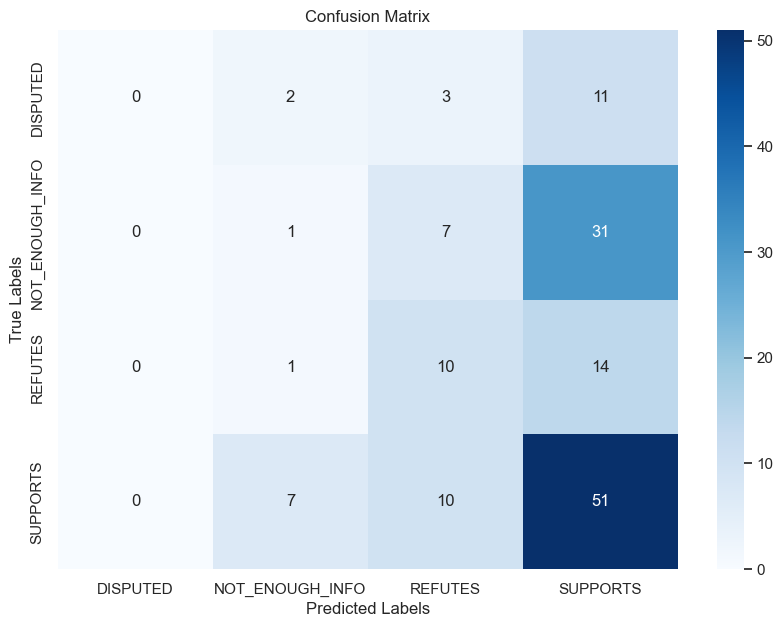

In [201]:
# Plotting the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

C:\Users\Clare\AppData\Local\Temp\ipykernel_14852\1162323039.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='claim_label', data=output_df, palette='Set2')  # Set2 is a nice color palette


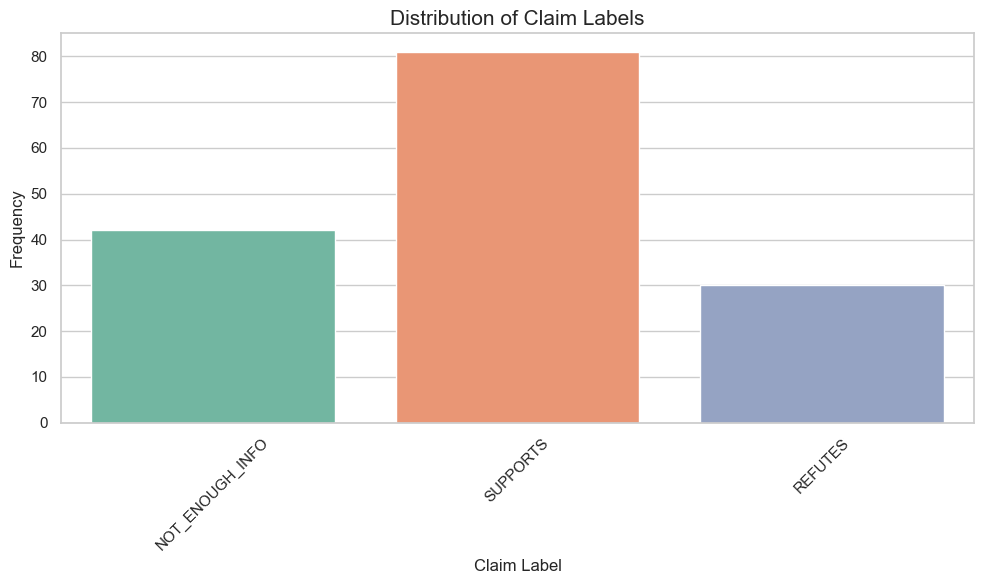

In [169]:
# Setting the aesthetic style of the plots
sns.set(style="whitegrid")

# Creating a count plot for claim_label
plt.figure(figsize=(10, 6))  # Set the figure size for the plot
ax = sns.countplot(x='claim_label', data=output_df, palette='Set2')  # Set2 is a nice color palette

# Adding titles and labels for clarity
ax.set_title('Distribution of Claim Labels', fontsize=15)
ax.set_xlabel('Claim Label', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Displaying the plot
plt.xticks(rotation=45)  # Rotate the x labels to make them more readable
plt.tight_layout()  # Adjusts plot parameters to give some padding
plt.show()


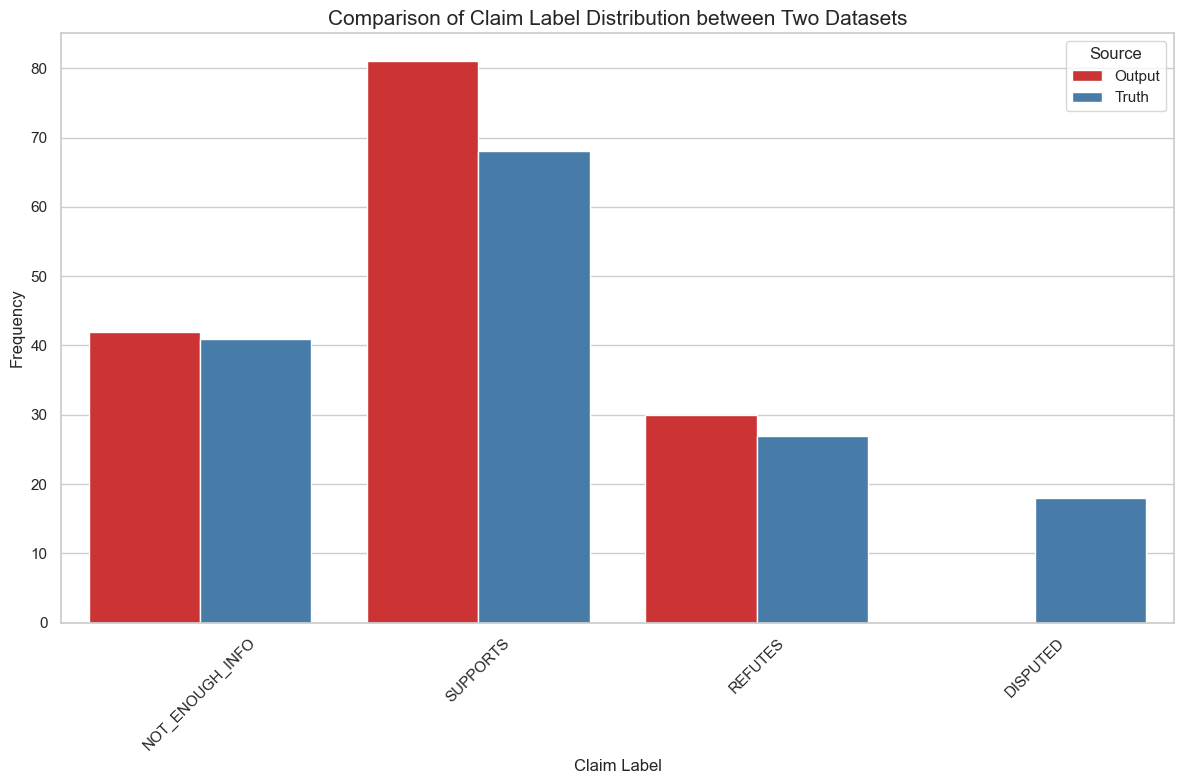

In [170]:
output_df['source'] = 'Output'
label_df['source'] = 'Truth'
combined_df = pd.concat([output_df, label_df])

# Plotting
plt.figure(figsize=(12, 8))
sns.countplot(x='claim_label', hue='source', data=combined_df, palette='Set1')
plt.title('Comparison of Claim Label Distribution between Two Datasets', fontsize=15)
plt.xlabel('Claim Label', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Source')
plt.tight_layout()
plt.show()